# Historical Events Question-Answering System

This notebook builds an end-to-end question-answering system over real-world Wikipedia articles using LlamaIndex and fully local LLMs via Ollama. It applies the core concepts from `llamaindex.API.ipynb` to a real dataset and extends the pipeline with persistent index storage, model comparison, and autonomous agentic reasoning.

**Sections:**
1. Data Ingestion - fetch Wikipedia articles using `WikipediaReader`
2. Index Creation - build a `VectorStoreIndex` over the ingested documents
3. Query Development - run natural language queries and evaluate answers
4. Evaluation - LLM-as-a-Judge faithfulness scoring across queries
5. Data Visualization - timeline of historical events in the knowledge base
6. Model Comparison - benchmark `llama3` vs `mistral` on the same queries
7. ReAct Agent - autonomous multi-tool reasoning over the knowledge base

### Pipeline Architecture
```mermaid
graph LR
    A[Wikipedia Articles] -->|WikipediaReader| B(Documents)
    B -->|VectorStoreIndex| C[(Vector Index)]
    C -->|persist| D[(Disk Storage)]
    D -.->|load_index_from_storage| C
    C -->|QueryEngine| E[Answers]
    C -->|ReActAgent| F[Agentic Reasoning]
```

**Tech Stack:**
- **LlamaIndex** - orchestration framework handling ingestion, indexing, and querying
- **Ollama (`llama3` / `mistral`)** - local LLMs for answer synthesis, runs on host machine
- **BAAI/bge-small-en-v1.5** - local embedding model for semantic search, runs inside Docker
- **Dataset** - curated Wikipedia corpus of historical events (≈10 pages)

In [1]:
# Auto-reload local modules (e.g., llamaindex_utils.py) on every cell execution
# Useful during development, no kernel restart needed after editing helper files
%load_ext autoreload
%autoreload 2

## 0. Setup

We configure two core components that power the entire pipeline:

- **LLM:** Ollama running `llama3` locally handles answer synthesis in the QueryEngine and ReAct Agent
- **Embedding Model:** `BAAI/bge-small-en-v1.5` via HuggingFace converts document chunks and queries into vectors for semantic search

The embedding model runs inside Docker, while the LLM runs on the host via Ollama (the container connects to Ollama using `http://host.docker.internal:11434`). No OpenAI API key is required.

Note: Wikipedia ingestion requires network access. The embedding model stays fixed throughout; we only swap the LLM when comparing `llama3` vs `mistral` in Section 6.

In [2]:
import nest_asyncio
nest_asyncio.apply()

import time                    
import logging
import matplotlib.pyplot as plt
from llamaindex_utils import setup_environment, configure_ollama

# Suppress verbose logs from LlamaIndex and HuggingFace during model loading
setup_environment(verbosity=logging.WARNING)

# Configure global LLM (Ollama/llama3) and embedding model (BAAI/bge-small-en-v1.5)
# These are set on llama_index.core.Settings and used automatically by all downstream components
# Note: the embedding model stays fixed throughout, only the LLM is swapped in Section 6
configure_ollama(model_name="llama3")

/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████| 199/199 [00:00<00:00, 14354.42it/s]


LlamaIndex configured: LLM=Ollama(llama3), Embeddings=BAAI/bge-small-en-v1.5


## 1. Data Ingestion

We use `WikipediaReader` (from `llama-index-readers-wikipedia`) to fetch full Wikipedia articles for a **curated historical events corpus** (≈10 pages). This improves retrieval coverage compared to a 3-page demo and reduces out-of-scope questions.

Two important parameters:
- `auto_suggest=False` - prevents the Wikipedia API from redirecting to unintended pages
- `set_user_agent()` - identifies our client to the Wikipedia API. Without this, requests
  may be rejected or rate-limited with a `JSONDecodeError`

Note: These are full Wikipedia articles, not summaries. The indexing step in Section 2 will chunk them into smaller nodes before embedding. This may take longer than a 3-page demo on first run.

In [3]:
from llama_index.readers.wikipedia import WikipediaReader
import wikipedia

# Identify our client to the Wikipedia API, prevents request rejection and rate-limiting
wikipedia.set_user_agent("UMD_DATA605_ClassProject/1.0 (smore12@umd.edu)")

# Define the historical events to load (dataset)
# Keep this list curated and stable for reproducible demos.
events = [
    "World War II",
    "World War I",
    "French Revolution",
    "Industrial Revolution",
    "American Civil War",
    "Cold War",
    "Renaissance",
    "Roman Empire",
    "Age of Discovery",
    "Space Race",
]
print(f"Fetching Wikipedia articles for: {events}...\n")

try:
    reader = WikipediaReader()
    # auto_suggest=False ensures exact page match, no API redirects to unrelated topics
    documents = reader.load_data(pages=events, auto_suggest=False)
except Exception as e:
    raise RuntimeError(
        f"Failed to fetch Wikipedia articles. "
        f"Check network connectivity from this environment.\nOriginal error: {e}"
    )

print(f"Successfully loaded {len(documents)} documents.\n")
for i, doc in enumerate(documents):
    doc.metadata["source"] = "wikipedia"
    doc.metadata["title"] = events[i]
    print(f"[{i+1}] {events[i]}")
    print(f"Size: {len(doc.text):,} characters")
    print(f"Metadata: {doc.metadata}")
    print(f"Preview: {doc.text[:120].strip()}...")
    print()

Fetching Wikipedia articles for: ['World War II', 'World War I', 'French Revolution', 'Industrial Revolution', 'American Civil War', 'Cold War', 'Renaissance', 'Roman Empire', 'Age of Discovery', 'Space Race']...

Successfully loaded 10 documents.

[1] World War II
Size: 86,339 characters
Metadata: {'source': 'wikipedia', 'title': 'World War II'}
Preview: World War II, or the Second World War (1 September 1939 – 2 September 1945), was a global conflict between two coalition...

[2] World War I
Size: 88,574 characters
Metadata: {'source': 'wikipedia', 'title': 'World War I'}
Preview: World War I, or the First World War (28 July 1914 – 11 November 1918), also known as The Great War, was a global conflic...

[3] French Revolution
Size: 84,941 characters
Metadata: {'source': 'wikipedia', 'title': 'French Revolution'}
Preview: The French Revolution was a period of political and societal change in France that began with the Estates General of 178...

[4] Industrial Revolution
Size: 112,888 c

## 2. Index Creation

We build a `VectorStoreIndex` from the Wikipedia documents. Internally, LlamaIndex runs the full ingestion pipeline automatically:

1. **Chunking** - each article is split into overlapping `Node` chunks using the default `SentenceSplitter`
2. **Embedding** - each chunk is converted into a 384-dimensional vector using `BAAI/bge-small-en-v1.5`
3. **Storing** - vectors are stored in an in-memory index and retrieved via cosine similarity at query time
4. **Persisting** - the index is saved to disk via `StorageContext` so it can be reloaded without re-embedding

> This step may take longer on first run for a larger corpus; subsequent runs load from disk instantly.

**Key architectural point:** The index is built **once** and reused across all sections, including the model comparison in Section 6. This is possible because the index only depends on the **embedding model** (which stays fixed), not on the LLM. Swapping `llama3` for `mistral` only affects the answer synthesis step; retrieval stays identical.

In [4]:
from llama_index.core import VectorStoreIndex, StorageContext, load_index_from_storage
import os

PERSIST_DIR = "./storage"

if not os.path.exists(PERSIST_DIR):
    print("Building the vector index (embedding all document chunks)...")
    print("This may take 30-60 seconds for large Wikipedia articles...\n")

    # from_documents() runs the full pipeline: chunking -> embedding -> storing
    index = VectorStoreIndex.from_documents(documents)

    # Persist index to disk, avoids re-embedding on subsequent runs
    index.storage_context.persist(persist_dir=PERSIST_DIR)
    print(f"Index built and persisted to '{PERSIST_DIR}'!")

else:
    print(f"Loading existing vector index from '{PERSIST_DIR}'...")

    # Load the persisted index, no re-embedding needed
    storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
    index = load_index_from_storage(storage_context)
    print("Index loaded successfully from disk!")

# Create the query engine, used for natural language queries in Section 3
query_engine = index.as_query_engine()

# index.docstore.docs stores all nodes generated during indexing
total_nodes = len(index.docstore.docs)

print(f"\nIndex ready.")
print(f"Documents indexed: {len(documents)}")
print(f"Total nodes indexed: {total_nodes}")
print(f"Query engine ready.")

Building the vector index (embedding all document chunks)...
This may take 30-60 seconds for large Wikipedia articles...

Index built and persisted to './storage'!

Index ready.
Documents indexed: 10
Total nodes indexed: 262
Query engine ready.


## 3. Query Development & Evaluation

The `QueryEngine` built in Section 2 accepts natural language questions and internally runs:

1. **Query Embedding** - the question is converted to a vector using the same embedding model
2. **Retrieval** - cosine similarity finds the most relevant Nodes from the index
3. **Synthesis** - retrieved context is passed to Ollama (`llama3`) to generate an answer

We submit several targeted queries spanning the indexed corpus.

After collecting answers, we evaluate them in Section 4 using LlamaIndex's native `FaithfulnessEvaluator`, which uses the LLM itself to judge whether each answer is grounded in the retrieved context.

In [5]:
# A set of natural language queries spanning the corpus
queries = [
    "What were the primary economic causes of the French Revolution?",
    "What event is widely considered the start of World War I?",
    "What event is widely considered the start of World War II in Europe?",
    "What was the main cause of the Cold War?",
    "What were the main outcomes of the American Civil War?",
]

# Store results for evaluation
results = []

for i, q in enumerate(queries):
    print(f"\nQuery {i+1}: {q}")
    print("-" * 60)

    # Time each query - local LLMs can take 10-30 seconds per response
    start = time.time()
    answer = query_engine.query(q)
    elapsed = time.time() - start

    answer_text = str(answer)
    print(f"Answer: {answer_text}")
    print(f"Response time: {elapsed:.1f}s")

    results.append({
        "query": q,
        "answer": answer_text,
        "response_obj": answer,
        "time": elapsed
    })


Query 1: What were the primary economic causes of the French Revolution?
------------------------------------------------------------
Answer: The primary economic causes of the French Revolution were a combination of social, economic, financial, and political factors. These included a financial crisis, widespread social distress, and poor harvests leading to high unemployment and food prices. Additionally, the level of debt was not high compared to Britain's, but tax rates varied widely from one region to another, causing resentment among all taxpayers. The complexity and lack of accountability in the system also contributed to the crisis.
Response time: 16.6s

Query 2: What event is widely considered the start of World War I?
------------------------------------------------------------
Answer: The assassination of Franz Ferdinand on June 28, 1914.
Response time: 10.0s

Query 3: What event is widely considered the start of World War II in Europe?
--------------------------------------

## 4. Evaluation

We evaluate answer quality using LlamaIndex's native `FaithfulnessEvaluator`.

Instead of a proxy metric like keyword coverage, this uses the **LLM as a judge**. It checks whether the synthesized answer is factually supported by the retrieved context, ensuring the model did not hallucinate information outside the knowledge base.

A response is marked:
- **Faithful** - the answer is grounded in the retrieved context
- **Not Faithful** - the answer contains information not found in the retrieved context

In [6]:
from llama_index.core.evaluation import FaithfulnessEvaluator
from llama_index.core import Settings

print("EVALUATION RESULTS (LLM-as-a-Judge)\n")

# Initialize the evaluator using our global LLM
evaluator = FaithfulnessEvaluator(llm=Settings.llm)

passed_count = 0
for i, result in enumerate(results):
    response_obj = result["response_obj"]

    # Run faithfulness evaluation asynchronously
    # Asks the LLM: "Is the answer supported by the retrieved context?"
    eval_result = await evaluator.aevaluate_response(response=response_obj)

    status = "Faithful" if eval_result.passing else "Not Faithful"
    print(f"Query {i+1}: {result['query']}")
    print(f"Result: {status}")
    print(f"Feedback: {eval_result.feedback}")
    print()

    if eval_result.passing:
        passed_count += 1

print(f"Overall Faithfulness Pass Rate: {passed_count / len(results):.0%}")

EVALUATION RESULTS (LLM-as-a-Judge)

Query 1: What were the primary economic causes of the French Revolution?
Result: Faithful
Feedback: YES

Query 2: What event is widely considered the start of World War I?
Result: Not Faithful
Feedback: NO

Query 3: What event is widely considered the start of World War II in Europe?
Result: Faithful
Feedback: YES

Query 4: What was the main cause of the Cold War?
Result: Faithful
Feedback: YES

Query 5: What were the main outcomes of the American Civil War?
Result: Faithful
Feedback: YES

Overall Faithfulness Pass Rate: 80%


> **Note:** The `FaithfulnessEvaluator` uses the LLM to judge faithfulness.
> With a local model like `llama3`, feedback is minimal ("YES"/"NO") compared to larger models like GPT-4 which provide detailed reasoning. The pass/fail verdict itself remains meaningful.

## 4b. Evaluation Observations

> **Note:** LLM generation is non-deterministic. Your exact scores will vary slightly on each run.

Using an LLM-as-a-Judge is the industry standard for RAG evaluation. It overcomes the limitations of keyword coverage by understanding semantics. Even if the model uses synonyms or rephrases the answer, the `FaithfulnessEvaluator` will correctly mark it as passing as long as the facts align with the Wikipedia context.

Other native evaluators provided by LlamaIndex include:

- **RelevancyEvaluator** - measures if the answer actually addresses the user's question
- **ContextRelevancyEvaluator** - measures if the retrieved nodes were relevant to the query

## 5. Data Visualization - Knowledge Base Coverage

To provide context for our QA system, we plot a timeline showing approximate date ranges of the historical events in our curated Wikipedia corpus.

This answers a practical question: **what time periods can our system reason about?**

| Event | Approximate Date Range |
|---|---|
| Renaissance | 1300 - 1600 |
| Age of Discovery | 1400 - 1700 |
| Industrial Revolution | 1760 - 1840 |
| French Revolution | 1789 - 1799 |
| American Civil War | 1861 - 1865 |
| World War I | 1914 - 1918 |
| World War II | 1939 - 1945 |
| Cold War | 1947 - 1991 |
| Space Race | 1955 - 1975 |
| Roman Empire | -27 - 476 |

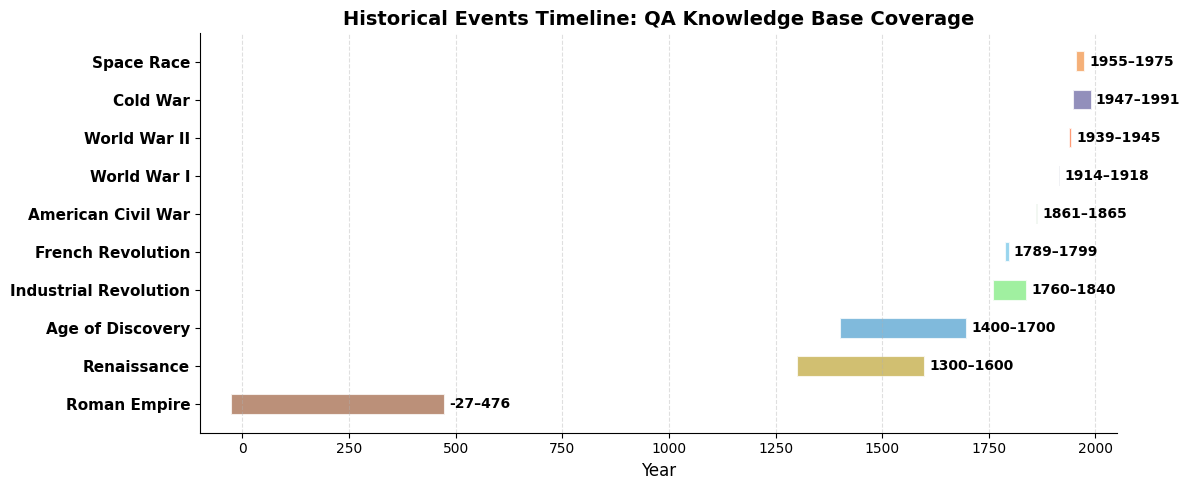

Timeline saved to: /git_root/class_project/data605/Spring2026/projects/UmdTask398_DATA605_Spring2026_LlamaIndex/historical_events_timeline.png


In [7]:
import os

# Define approximate date ranges and colors for each historical event
# Ordered chronologically by start date for a natural top-to-bottom reading
event_data = [
    {"name": "Roman Empire", "start": -27, "end": 476, "color": "#b07d62"},
    {"name": "Renaissance", "start": 1300, "end": 1600, "color": "#c9b458"},
    {"name": "Age of Discovery", "start": 1400, "end": 1700, "color": "#6aaed6"},
    {"name": "Industrial Revolution", "start": 1760, "end": 1840, "color": "lightgreen"},
    {"name": "French Revolution", "start": 1789, "end": 1799, "color": "skyblue"},
    {"name": "American Civil War", "start": 1861, "end": 1865, "color": "#9cc69b"},
    {"name": "World War I", "start": 1914, "end": 1918, "color": "#8d99ae"},
    {"name": "World War II", "start": 1939, "end": 1945, "color": "coral"},
    {"name": "Cold War", "start": 1947, "end": 1991, "color": "#7f7caf"},
    {"name": "Space Race", "start": 1955, "end": 1975, "color": "#f4a261"},
]

fig, ax = plt.subplots(figsize=(12, 5))

# Draw a horizontal bar for each event
for i, event in enumerate(event_data):
    duration = event["end"] - event["start"]
    ax.barh(
        i,
        duration,
        left=event["start"],
        height=0.55,
        color=event["color"],
        alpha=0.85,
        edgecolor="white",
        linewidth=1.5,
    )
    # Place date labels to the right of each bar
    ax.text(
        event["end"] + 10,
        i,
        f"{event['start']}–{event['end']}",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

# Formatting
ax.set_yticks(range(len(event_data)))
ax.set_yticklabels([e["name"] for e in event_data], fontsize=11, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_title("Historical Events Timeline: QA Knowledge Base Coverage", fontsize=14, fontweight="bold")
# xlim set to give padding before earliest event (-27) and after latest (1991)
ax.set_xlim(-100, 2050)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
output_path = os.path.join(os.getcwd(), "historical_events_timeline.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Timeline saved to: {output_path}")

## 6. Model Comparison: llama3 vs mistral

One of LlamaIndex's key strengths is being **model-agnostic**: the index and retrieval pipeline stay completely unchanged, only the LLM backend is swapped. This is possible because retrieval depends on the **embedding model** (fixed), not the LLM.

We compare two fully local Ollama models on the same query:

| Model | Description |
|---|---|
| `llama3` | Meta's open-source LLM - strong reasoning, slower response |
| `mistral` | Mistral AI's 7B model - faster and more lightweight, competitive quality |

> **Pre-requisite:** Ensure both models are available locally before running this cell:
>
> ```
> ollama pull llama3
> ollama pull mistral
> ```

In [8]:
# Comparison query - identical question posed to both models
comparison_query = "What were the main causes of the French Revolution?"

# Models to compare - both run fully locally via Ollama
models_to_compare = ["llama3", "mistral"]
comparison_results = {}
response_times = []

for model_name in models_to_compare:
    print(f"\nTesting model: {model_name}")

    # Swap only the LLM in global Settings - index and embeddings remain unchanged
    configure_ollama(model_name=model_name)

    # Create a new query engine instance pointing to the updated LLM
    qe = index.as_query_engine()

    # Time the full query - embedding + retrieval + LLM synthesis
    start = time.time()
    response = qe.query(comparison_query)
    elapsed = time.time() - start

    answer_text = str(response)
    print(f"Response time: {elapsed:.1f}s")
    print(f"Answer: {answer_text}")

    comparison_results[model_name] = {
        "answer": answer_text,
        "response_obj": response,
        "time": elapsed
    }
    response_times.append(elapsed)

# Reset back to llama3 after comparison - ensures the ReAct Agent cell uses llama3
configure_ollama(model_name="llama3")
print("\nLLM reset to llama3 for subsequent cells.")


Testing model: llama3


Loading weights: 100%|█████████████████████████████████████████| 199/199 [00:00<00:00, 10980.14it/s]


LlamaIndex configured: LLM=Ollama(llama3), Embeddings=BAAI/bge-small-en-v1.5
Response time: 13.5s
Answer: The main causes of the French Revolution included a combination of social, political, and economic factors. These factors included a financial crisis and widespread social distress, which led to the convocation of the Estates General in May 1789, its first meeting since 1614. The representatives of the Third Estate broke away and re-constituted themselves as a National Assembly in June.

Testing model: mistral


Loading weights: 100%|██████████████████████████████████████████| 199/199 [00:00<00:00, 9217.84it/s]


LlamaIndex configured: LLM=Ollama(mistral), Embeddings=BAAI/bge-small-en-v1.5
Response time: 26.9s
Answer:  The French Revolution was caused by a combination of factors including social, political, and economic issues that culminated in a crisis towards the late 1780s. One key aspect was the rapid population growth which led to an increased middle class but decreased living standards for wage laborers and peasant farmers. Economic recession, bad harvests, and high unemployment contributed to a financial and political crisis. The state also faced a debt crisis due to varying tax rates, inconsistent collection, and resistance from regional Parlements that approved financial policy. These issues led to the convocation of the Estates General in 1789, which became radicalized by the struggle for control of public finances. Additionally, Enlightenment critiques of social institutions, the American Revolution, European revolts of the 1780s, and scandals such as the Affair of the Diamond Neckl

Loading weights: 100%|█████████████████████████████████████████| 199/199 [00:00<00:00, 10186.31it/s]


LlamaIndex configured: LLM=Ollama(llama3), Embeddings=BAAI/bge-small-en-v1.5

LLM reset to llama3 for subsequent cells.


In [9]:
# Run FaithfulnessEvaluator on each model's response
faithfulness_scores = []
for m in models_to_compare:
    eval_result = await evaluator.aevaluate_response(
        response=comparison_results[m]["response_obj"]
    )
    faithfulness_scores.append(1 if eval_result.passing else 0)

# Print comparison summary
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<10} {'Response Time':>15} {'Faithful':>12} {'Word Count':>12}")
print("-" * 60)
for m, rt, fs in zip(models_to_compare, response_times, faithfulness_scores):
    faithful = "Yes" if fs == 1 else "No"
    word_count = len(comparison_results[m]["answer"].split())
    print(f"{m:<10} {rt:>13.1f}s {faithful:>12} {word_count:>11} words")

MODEL COMPARISON SUMMARY
Model        Response Time     Faithful   Word Count
------------------------------------------------------------
llama3              13.5s          Yes          60 words
mistral             26.9s          Yes         144 words


### 6b. Model Comparison Summary

We evaluate both models across three metrics:

| Metric | Description |
|---|---|
| **Response Time** | How long each model took to synthesize an answer |
| **Faithfulness** | Whether the answer is grounded in retrieved context (`FaithfulnessEvaluator`) |
| **Word Count** | How verbose each model's response was |

> **Note:** Mistral produced a longer, more detailed answer, covering Enlightenment critiques, Louis XVI's indecision, and court scandals. While llama3 gave a more concise response. Both answers were faithful to the retrieved Wikipedia context. Response time scales with output length, which explains mistral's slower response.

## 7. Autonomous ReAct Agent

The final section extends our pipeline from a simple QueryEngine to an **autonomous agent** capable of multi-step reasoning.

A **ReAct Agent** (Reasoning + Acting) operates in an iterative loop:
1. **Thought** - the agent reasons about what information it needs
2. **Action** - it selects and calls the most appropriate tool
3. **Observation** - it reads the tool's output and decides whether it has enough to answer
4. This loop repeats until the agent has a final answer

We equip the agent with two tools:

| Tool | Type | Purpose |
|---|---|---|
| `wikipedia_history_db` | `QueryEngineTool` | Answers factual questions using our indexed Wikipedia articles |
| `subtract_years` | `FunctionTool` | Calculates the number of years between two historical events |

We then pose a multi-part query that requires **both** tools. The agent must look up two dates from the knowledge base and then compute the difference arithmetically. Setting `verbose=True` exposes the agent's full internal reasoning trace so we can follow each Thought -> Action -> Observation step.

In [10]:
from llama_index.core.tools import QueryEngineTool, ToolMetadata, FunctionTool
from llama_index.core.agent import ReActAgent
from llama_index.core import Settings

# Tool 1: Wikipedia QA Engine - wraps our existing index for factual lookups
wiki_tool = QueryEngineTool(
    query_engine=index.as_query_engine(),
    metadata=ToolMetadata(
        name="wikipedia_history_db",
        description=(
            "Use this tool to answer factual historical questions about the indexed "
            "historical events corpus (multiple Wikipedia articles). "
            "Input must be a specific natural language question, for example: "
            "'What year did the French Revolution start?' or "
            "'When did World War II begin in Europe?'"
        ),
    ),
)

# Tool 2: Year difference calculator - custom Python function exposed as a tool
def subtract_years(year1: int, year2: int) -> int:
    """Calculates the absolute difference in years between two historical events."""
    return abs(year1 - year2)

math_tool = FunctionTool.from_defaults(
    fn=subtract_years,
    name="subtract_years",
    description=(
        "Compute the absolute difference between two integer years. "
        "Use this tool for ALL year arithmetic (do not do mental math). "
        "Example: subtract_years(2026, 1945) -> 81."
    ),
)

# Create the ReAct Agent with both tools
# verbose=True exposes the full Thought -> Action -> Observation reasoning trace
# max_iterations=10 prevents infinite reasoning loops
agent = ReActAgent(
    tools=[wiki_tool, math_tool],
    llm=Settings.llm,
    verbose=True,
    max_iterations=10,
)

print("AGENTIC REASONING DEMO")

# Multi-part prompt requiring both tools:
# wiki_tool - to look up the two start years
# math_tool - to compute the difference
prompt = (
    "In what year did the French Revolution start? "
    "In what year did World War II start? "
    "How many years passed between these two events?"
)

print(f"User Prompt: {prompt}\n")

# await works in this environment — kernel supports top-level async natively
response = await agent.run(prompt)
print(f"\nFinal Synthesized Answer: {response}")

AGENTIC REASONING DEMO
User Prompt: In what year did the French Revolution start? In what year did World War II start? How many years passed between these two events?

[tick] add: AgentWorkflowStartEvent(user_msg='In what year did the French Revolution start? In w...', chat_history=None, memory=None, max_iterations=None, early_stopping_method=None)
[init_run:0] started from AgentWorkflowStartEvent
[init_run:0] complete with AgentInput
[tick] add: AgentInput(input=[ChatMessage(role=<MessageRole.USER: 'user'>, additional_kwargs={}, blocks=[TextBlock(block_type='text', text='In what year did the French Revolution start? In what year did World ...
[setup_agent:0] started from AgentInput
[setup_agent:0] complete with AgentSetup
[tick] add: AgentSetup(input=[ChatMessage(role=<MessageRole.USER: 'user'>, additional_kwargs={}, blocks=[TextBlock(block_type='text', text='In what year did the French Revolution start? In what year did World ...
[run_agent_step:0] started from AgentSetup
[run_agent_

> **Note on Tool Design:** The `description` field in `ToolMetadata` is critical. It acts as the agent's instruction manual for when and how to call the tool. A vague description causes the agent to call tools incorrectly or with missing inputs. Specific, example-driven descriptions significantly improve agent reliability.

## Summary

This notebook applied the core LlamaIndex concepts from `llamaindex.API.ipynb` to a curated Wikipedia corpus, building a complete historical question-answering system from ingestion to agentic reasoning.

| Section | What was built | Key takeaway |
|---|---|---|
| 1. Data Ingestion | `WikipediaReader` pipeline | A curated event list improves coverage; `set_user_agent` + `auto_suggest=False` improve reliability |
| 2. Index Creation | `VectorStoreIndex` + `StorageContext` | The index is persisted to disk (`./storage`) to avoid rebuilding on subsequent runs |
| 3. Query Development | A set of cross-corpus queries | A larger corpus reduces out-of-scope questions and improves retrieval coverage |
| 4. Evaluation | `FaithfulnessEvaluator` (LLM-as-a-Judge) | Faithfulness checks grounding in retrieved context (but does not guarantee perfect arithmetic) |
| 5. Visualization | Historical events timeline | The chart summarizes which historical periods the knowledge base can answer about |
| 6. Model Comparison | `llama3` vs `mistral` benchmarked | Swapping LLMs requires one line of code; index + retrieval stay unchanged |
| 7. ReAct Agent | Autonomous multi-tool reasoning | Agent combines factual lookup with tool-based year arithmetic (`subtract_years`) |